# Activity scoring of senescence marker genes 
#### To generate a score for each cell/sample, the z-scored expression values were filtered for the genes of interest, converted to indicate concordance or discordance with the direction of change in the gene set (includes directionality metadata), and averaged. A positive resulting score indicates a similar expression pattern to the gene-set signature compared to the other cells/samples in the data set

In [1]:
from utils import *

In [22]:
data_dir = '/ocean/projects/cis240075p/asachan/datasets/senescence_datasets/mouse_liver'

In [27]:
normalized_counts = pd.read_csv(os.path.join(data_dir, 'Trf2_Liver_NormCounts_GSEA.gct.txt'), sep='\t', skiprows=2)
expr_df = normalized_counts.set_index('NAME')
expr_df = expr_df.drop('Description', axis=1)
expr_df = expr_df.select_dtypes(include=[np.number])
expr_df = expr_df.dropna()  # Remove rows with NaN values
display(expr_df.head())


,AV01,AV02,AV03,AV04,AV05,AV06,AV07,AV08,AV09,AV10,AV11,AV12,AV13,AV14,AV15,AV16,AV17,AV18,AV19,AV20
NAME,,,,,,,,,,,,,,,,,,,,
Xkr4,4.202855,0.000000,0.000000,0.000000,5.489411,0.701450,3.115962,0.000000,0.000000,1.242640,0.000000,0.000000,0.000000,0.000000,0.000000,1.030429,1.642052,0.000000,0.000000,0.781083
Sox17,104.020668,68.775083,40.865415,66.229103,112.532935,65.234839,41.753890,22.378785,36.146543,57.161443,35.110845,77.113697,34.697691,77.299154,32.474227,69.038745,38.588215,25.167334,75.172195,53.894700
Mrpl15,799.593217,741.977338,1061.298871,837.755151,796.879567,824.203605,1042.600871,1112.053462,1459.572458,884.759722,918.935553,823.714489,965.752406,784.883722,875.756567,771.791345,1004.935644,1039.201182,818.875780,712.347336
Lypla1,3446.341331,3227.138511,1094.952743,1937.846361,2074.082640,3115.840354,2166.839945,587.873463,575.851815,1656.439199,2242.251179,3189.702914,739.253588,2547.304444,2159.012302,3899.143454,1620.705034,557.875912,2234.117643,2814.240627
LOC118567656,3.152141,5.290391,0.000000,0.000000,0.000000,2.104350,1.246385,2.582167,0.000000,1.242640,3.632156,4.673557,0.000000,0.000000,2.095111,3.091287,0.821026,0.000000,4.009184,2.343248


## Remove outlier and create a new expr_df

In [28]:
expr_df_no_outliers = expr_df.drop(columns=['AV03'])
#expr_df_no_outliers = expr_df
display(expr_df_no_outliers.head())

,AV01,AV02,AV04,AV05,AV06,AV07,AV08,AV09,AV10,AV11,AV12,AV13,AV14,AV15,AV16,AV17,AV18,AV19,AV20
NAME,,,,,,,,,,,,,,,,,,,
Xkr4,4.202855,0.000000,0.000000,5.489411,0.701450,3.115962,0.000000,0.000000,1.242640,0.000000,0.000000,0.000000,0.000000,0.000000,1.030429,1.642052,0.000000,0.000000,0.781083
Sox17,104.020668,68.775083,66.229103,112.532935,65.234839,41.753890,22.378785,36.146543,57.161443,35.110845,77.113697,34.697691,77.299154,32.474227,69.038745,38.588215,25.167334,75.172195,53.894700
Mrpl15,799.593217,741.977338,837.755151,796.879567,824.203605,1042.600871,1112.053462,1459.572458,884.759722,918.935553,823.714489,965.752406,784.883722,875.756567,771.791345,1004.935644,1039.201182,818.875780,712.347336
Lypla1,3446.341331,3227.138511,1937.846361,2074.082640,3115.840354,2166.839945,587.873463,575.851815,1656.439199,2242.251179,3189.702914,739.253588,2547.304444,2159.012302,3899.143454,1620.705034,557.875912,2234.117643,2814.240627
LOC118567656,3.152141,5.290391,0.000000,0.000000,2.104350,1.246385,2.582167,0.000000,1.242640,3.632156,4.673557,0.000000,0.000000,2.095111,3.091287,0.821026,0.000000,4.009184,2.343248


## Plot genesets

In [29]:
sensig_geneset = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/SenSig_DEGs.csv'
fridman_down_orthologs = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/fridman_down_orthologs.csv'
fridman_up_orthologs = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/fridman_up_orthologs.csv'
senmayo_geneset = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/SAUL_SEN_MAYO_UP_IN_SEN.v2024.1.Mm.gmt'
cell_age_orthologs = '/ocean/project s/cis240075p/asachan/datasets/gene_sets/mouse/cellAge_orthologs.csv'
cell_age_human = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/human/cellAge/cellage3.tsv'
hepatocyte_sen = '/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/SHGS_ortholog_map.csv'

#### Senescent Hepatocyte Gene Signature

In [30]:
# load from ortholog csv
hepatocyte_senescent_up = pd.read_csv(hepatocyte_sen, sep=',', header=0)['mouse_gene_symbol'].tolist()
display(hepatocyte_senescent_up[0:5])


['Lif', 'Itgav', 'Osbpl3', 'Ifngr1', 'Thbs1']

#### SenSig

In [6]:
#SenSig
sensig_genes = pd.read_csv(sensig_geneset, skiprows=1)
print(sensig_genes.head())
sensig_up_genes = sensig_genes[sensig_genes['logFC'] > 0]['Gene'].tolist()  
sensig_down_genes = sensig_genes[sensig_genes['logFC'] < 0]['Gene'].tolist()
print(len(sensig_up_genes))
print(len(sensig_down_genes))


      Gene     logFC    logCPM           F        PValue           FDR
0  Aldh1a3 -1.537131  5.312493  317.399525  2.000000e-11  2.250000e-07
1   Card10 -1.329801  6.905892  308.235873  2.460000e-11  2.250000e-07
2   Errfi1 -1.277384  9.671747  285.153969  4.270000e-11  2.610000e-07
3      Tek -1.774617  8.228041  240.112909  1.430000e-10  6.560000e-07
4     Car8 -2.359974  5.802668  203.895757  4.490000e-10  1.640000e-06
8567
9069


#### Fridman

In [ ]:
#Fridman gene sets
fridman_down_orthologs = pd.read_csv(fridman_down_orthologs, sep=',', header=0)['ortholog_name'].tolist()
fridman_up_orthologs = pd.read_csv(fridman_up_orthologs, sep=',', header=0)['ortholog_name'].tolist()
display(fridman_down_orthologs[0:5])
display(fridman_up_orthologs[0:5])


['Aldh1a7', 'Aldh1a1', 'Bmi1', 'Ccn4', 'Ccnb1']

['Aldh1a3', 'Aopep', 'Ccn2', 'Ccnd1', 'Cd44']

#### SenMayo

In [8]:
#SenMayo
senmayo_genes = pd.read_csv(senmayo_geneset, sep='\t', header=None)
senmayo_up_genes = senmayo_genes.iloc[0, 2:].dropna().tolist()
display(senmayo_up_genes[0:5])


['Acvr1b', 'Ang', 'Angpt1', 'Angptl4', 'Areg']

#### CellAge

In [9]:
cellage_orthologs = pd.read_csv(cell_age_orthologs, sep=',', header=0)
cellage_human = pd.read_csv(cell_age_human, sep='\t', header=0)
# Merge based on initial_alias (from orthologs) matching Gene symbol (from cellage)
merged = pd.merge(
    cellage_orthologs[['ortholog_name', 'initial_alias']], # Keep only these columns
    cellage_human[['Gene symbol', 'Senescence Effect']],
    left_on='initial_alias',
    right_on='Gene symbol',
    how='left'
)

# Clean up the merged dataframe
merged = merged.drop('Gene symbol', axis=1)  # Remove the redundant column
cellage_ortholog_genes = merged.rename(columns={'initial_alias': 'human_gene'})
# get the cellage_up_genes as ortholog_name
cellage_up_genes = cellage_ortholog_genes[cellage_ortholog_genes['Senescence Effect'] == 'Induces']['ortholog_name'].tolist()
display(cellage_up_genes[0:5])
# get the cellage_down_genes as ortholog_name 
cellage_down_genes = cellage_ortholog_genes[cellage_ortholog_genes['Senescence Effect'] == 'Inhibits']['ortholog_name'].tolist()
display(cellage_down_genes[0:5])


['Aak1', 'Abcb1b', 'Abcb1a', 'Abi3', 'Abi3bp']

['Abcc6', 'Acer2', 'Acer2', 'Acer2', 'Acer2']

#### Get overlap between genesets

In [10]:
# Create lists of gene sets
up_genesets = {
    'SenSig': sensig_up_genes,
    'Fridman': fridman_up_orthologs,
    'SenMayo': senmayo_up_genes,
    'CellAge': cellage_up_genes
}

down_genesets = {
    'SenSig': sensig_down_genes,
    'Fridman': fridman_down_orthologs,
    'SenMayo': [],  # Empty list for SenMayo
    'CellAge': cellage_down_genes
}
#save to txt the sizes of the genesets  
with open('/ocean/projects/cis240075p/asachan/datasets/senescence_datasets/mouse_liver/gene_set_sizes.txt', 'w') as f:
    f.write(f"SenSig Up: {len(sensig_up_genes)}\n")
    f.write(f"Fridman Up: {len(fridman_up_orthologs)}\n")
    f.write(f"SenMayo Up: {len(senmayo_up_genes)}\n")
    f.write(f"CellAge Up: {len(cellage_up_genes)}\n")
    f.write(f"SenSig Down: {len(sensig_down_genes)}\n")
    f.write(f"Fridman Down: {len(fridman_down_orthologs)}\n")
    f.write(f"SenMayo Down: 0\n")
    f.write(f"CellAge Down: {len(cellage_down_genes)}\n")

In [11]:
# # Create figure with two subplots
# fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
# # Create matrices for both up and down regulated genes
# up_percent, up_count = create_overlap_data(up_genesets)
# down_percent, down_count = create_overlap_data(down_genesets)
# # Plot both heatmaps
# plot_overlap_heatmap(up_percent, 'Up-regulated Gene Set Overlap', ax1, is_up=True)
# plot_overlap_heatmap(down_percent, 'Down-regulated Gene Set Overlap', ax2, is_up=False)

# plt.tight_layout()
# #save as pdf 
# #fig.savefig('/ocean/projects/cis240075p/asachan/datasets/senescence_datasets/mouse_liver/figures/gene_set_overlap.pdf', bbox_inches='tight')

## Plot the senescence scores

In [31]:
#Hepatocyte Senescence Signature
hepatocyte_sen_scores = calculate_senescence_score(expr_df_no_outliers, up_genes=hepatocyte_senescent_up)
hepatocyte_sen_scores['category'] = hepatocyte_sen_scores.index.map(map_sample_to_category_trf2)

Using 96 upregulated genes


In [11]:
#SenSig
sensig_scores = calculate_senescence_score(expr_df_no_outliers, up_genes=sensig_up_genes, down_genes=sensig_down_genes)
sensig_up_scores = calculate_senescence_score(expr_df_no_outliers, up_genes=sensig_up_genes)
sensig_down_scores = calculate_senescence_score(expr_df_no_outliers, down_genes=sensig_down_genes)
# add category to the sample names
sensig_scores['category'] = sensig_scores.index.map(map_sample_to_category_ercc1)
sensig_up_scores['category'] = sensig_up_scores.index.map(map_sample_to_category_ercc1)
sensig_down_scores['category'] = sensig_down_scores.index.map(map_sample_to_category_ercc1)


Using 7201 upregulated genes
Using 7402 downregulated genes
Using 7201 upregulated genes
Using 7402 downregulated genes


In [12]:
#Fridman
fridman_scores = calculate_senescence_score(expr_df_no_outliers, up_genes=fridman_up_orthologs, down_genes=fridman_down_orthologs)
fridman_up_scores = calculate_senescence_score(expr_df_no_outliers, up_genes=fridman_up_orthologs)
fridman_down_scores = calculate_senescence_score(expr_df_no_outliers, down_genes=fridman_down_orthologs)
fridman_up_scores['category'] = fridman_up_scores.index.map(map_sample_to_category_ercc1)
fridman_down_scores['category'] = fridman_down_scores.index.map(map_sample_to_category_ercc1)
fridman_scores['category'] = fridman_scores.index.map(map_sample_to_category_ercc1)

Using 83 upregulated genes
Using 13 downregulated genes
Using 83 upregulated genes
Using 13 downregulated genes


In [ ]:
#SenMayo
senmayo_scores = calculate_senescence_score(expr_df_no_outliers, up_genes=senmayo_up_genes)
senmayo_scores['category'] = senmayo_scores.index.map(map_sample_to_category_ercc1)
display(senmayo_scores.head())


Using 107 upregulated genes


,senescence_score,category
AV01,-0.016834,WT
AV02,2.436947,WT
AV03,-0.108119,WT
AV04,0.133187,WT
AV05,0.189293,WT


In [14]:
#CellAge
cellage_scores = calculate_senescence_score(expr_df_no_outliers, up_genes=cellage_up_genes, down_genes=cellage_down_genes)
cellage_up_scores = calculate_senescence_score(expr_df_no_outliers, up_genes=cellage_up_genes)
cellage_down_scores = calculate_senescence_score(expr_df_no_outliers, down_genes=cellage_down_genes)
cellage_scores['category'] = cellage_scores.index.map(map_sample_to_category_ercc1)
cellage_up_scores['category'] = cellage_up_scores.index.map(map_sample_to_category_ercc1)
cellage_down_scores['category'] = cellage_down_scores.index.map(map_sample_to_category_ercc1)


Using 353 upregulated genes
Using 453 downregulated genes
Using 353 upregulated genes
Using 453 downregulated genes


In [32]:
# custom_colors = {
#     'WT': '#66C2D7',  
#     'Ercc1 LKO': '#1E3A8A',
# }

custom_colors = {
    'Ctrl Low-Fat diet': '#66C2D7',      # Soft teal blue
    'Trf2 KO Low-Fat diet': '#2E86AB',   # Deeper teal blue
    'Ctrl Western diet': '#C4A0E7',      # Light lavender
    'Trf2 KO Western diet': '#4B0082'    # Indigo
}

findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.


findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font f

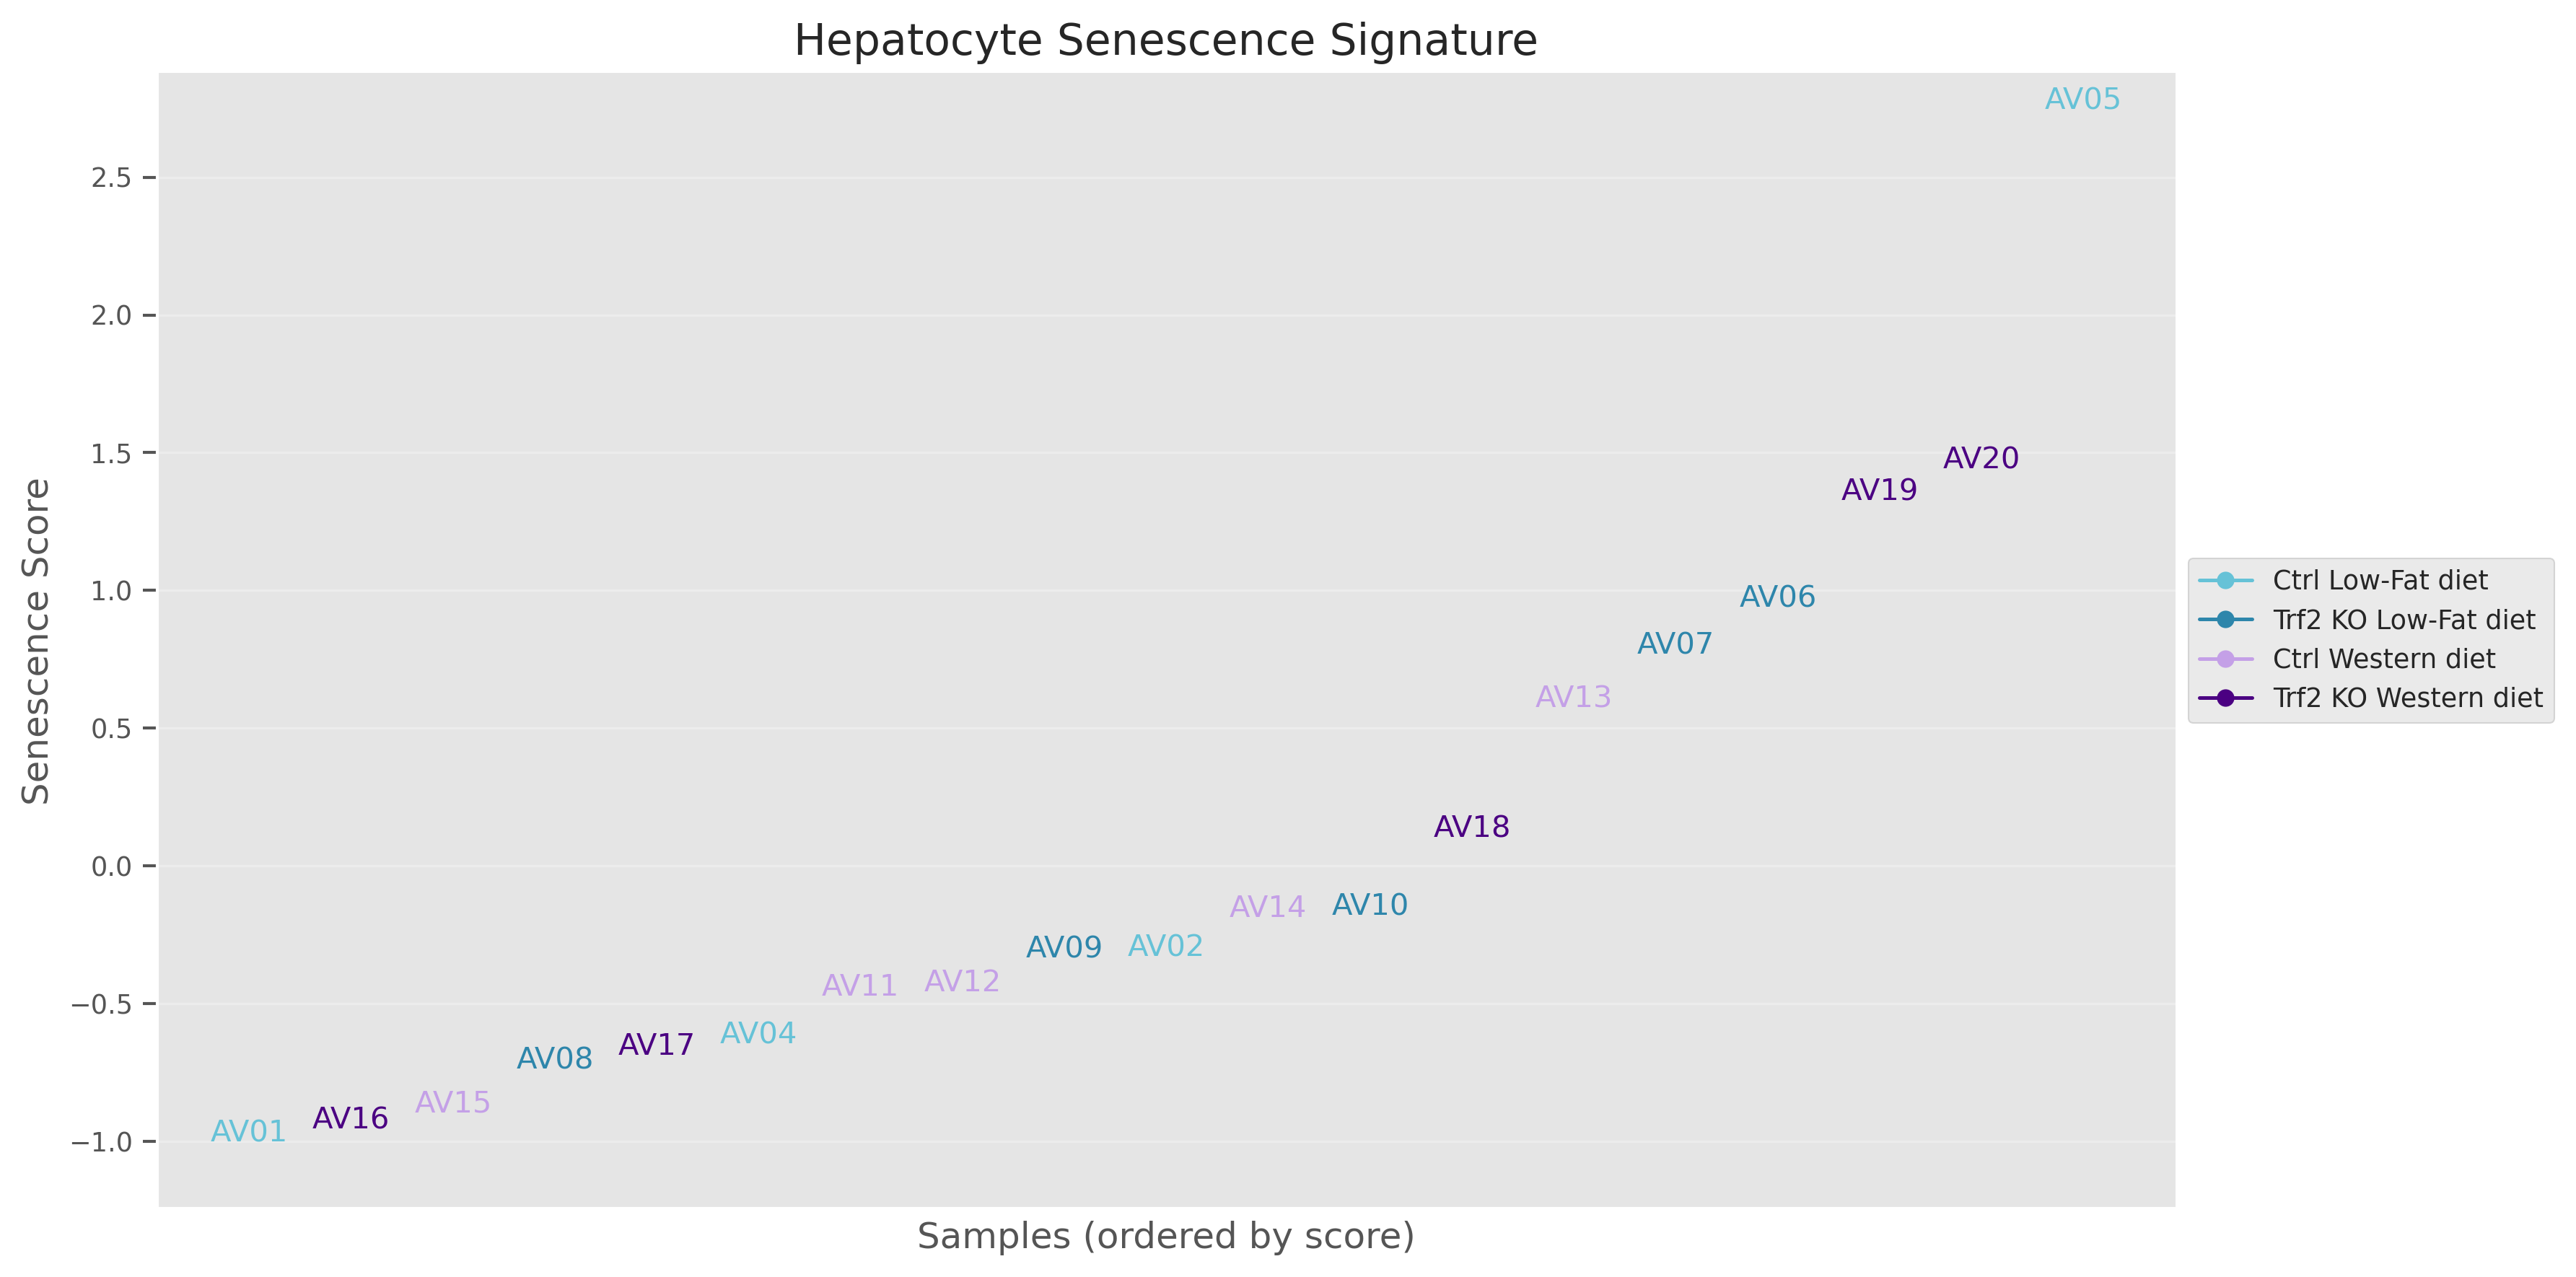

In [33]:
plot_scores_scatter(hepatocyte_sen_scores, 
                   category_colors=custom_colors,
                   title="Hepatocyte Senescence Signature",
                   ylabel="Senescence Score")


In [34]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Set scientific style
plt.style.use(['ggplot'])
plt.rcParams.update({
    'font.family': 'Arial',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 300,
    'figure.figsize': (6, 4)
})

In [18]:
# Create a list of your score dataframes
all_scores = [sensig_scores, fridman_scores, senmayo_scores, cellage_scores]

# Combine scores
combined_scores = pd.concat(all_scores, axis=0)
mean_per_sample = (combined_scores
                  .groupby([combined_scores.index, 'category'])['senescence_score']
                  .mean()
                  .reset_index()
                  .rename(columns={'level_0': 'sample'}))

In [36]:
display(hepatocyte_sen_scores)

,senescence_score,category
AV01,-1.056937,Ctrl Low-Fat diet
AV02,-0.383186,Ctrl Low-Fat diet
AV04,-0.699008,Ctrl Low-Fat diet
AV05,2.691323,Ctrl Low-Fat diet
AV06,0.885629,Trf2 KO Low-Fat diet
AV07,0.715853,Trf2 KO Low-Fat diet
AV08,-0.791653,Trf2 KO Low-Fat diet
AV09,-0.386738,Trf2 KO Low-Fat diet
AV10,-0.232555,Trf2 KO Low-Fat diet
AV11,-0.525276,Ctrl Western diet


/ocean/projects/cis240075p/asachan/bio_informatics_analysis/bulk_rna_analysis/liver_mice/utils.py:357: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  violin = sns.violinplot(
/ocean/projects/cis240075p/asachan/bio_informatics_analysis/bulk_rna_analysis/liver_mice/utils.py:419: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font family 'Arial' not found.
findfont: Font 

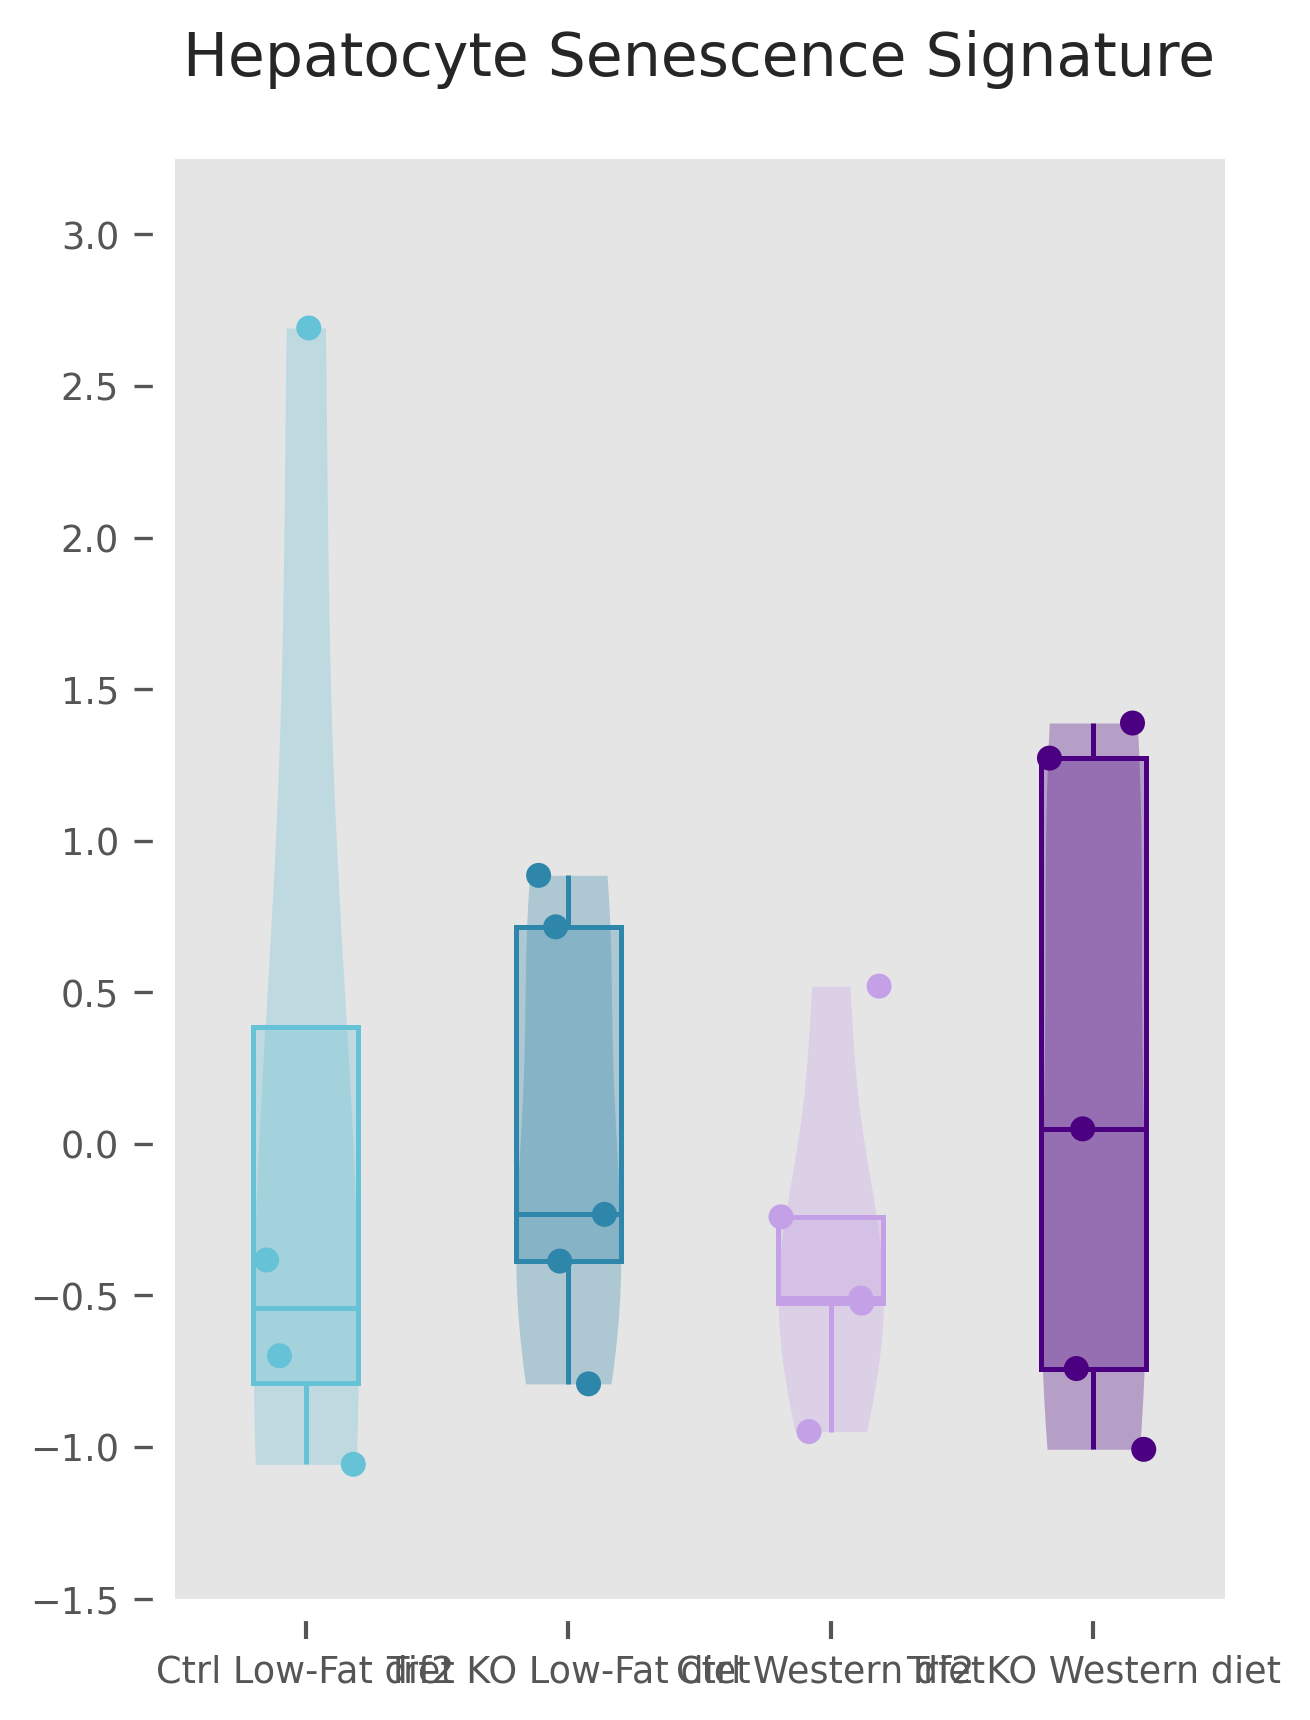

<Figure size 1800x1200 with 0 Axes>

In [35]:
fig = plot_violin_box_combo(
    data=hepatocyte_sen_scores,
    x_var='category',
    y_var='senescence_score',
    title='Hepatocyte Senescence Signature',
    x_ticks=hepatocyte_sen_scores['category'].unique(),
    palette=custom_colors
)

# Display the plot
from IPython.display import display
display(fig)
# save as pdf 
#fig.savefig('/ocean/projects/cis240075p/asachan/datasets/senescence_datasets/mouse_liver/figures/cellage_scores.pdf', bbox_inches='tight')

# Plotting the expression of certain genes

In [ ]:
from scipy import stats
import itertools
from statannotations.Annotator import Annotator

pnpla2_expr = pd.DataFrame()
pnpla2_expr['Expression'] = expr_df_no_outliers.loc['Pnpla2']
pnpla2_expr['category'] = pnpla2_expr.index.map(map_sample_to_category)

# Create figure
plt.figure(figsize=(10, 6))

# Create violin plot and store the axis
ax = sns.violinplot(data=pnpla2_expr, x='category', y='Expression', palette=custom_colors)

# Perform statistical tests and create pairs for annotation
categories = pnpla2_expr['category'].unique()
pairs = list(itertools.combinations(categories, 2))
pvalues = []

for cat1, cat2 in pairs:
    sample1 = pnpla2_expr[pnpla2_expr['category'] == cat1]['Expression']
    sample2 = pnpla2_expr[pnpla2_expr['category'] == cat2]['Expression']
    _, pval = stats.ttest_ind(sample1, sample2)
    pvalues.append(pval)

# Convert p-values to asterisk notation
def pval_to_stars(pval):
    if pval < 0.001:
        return '***'
    elif pval < 0.01:
        return '**'
    elif pval < 0.05:
        return '*'
    else:
        return 'ns'

# Add statistical annotations
annotator = Annotator(ax, pairs, data=pnpla2_expr, x='category', y='Expression')
annotator.configure(text_format='star', loc='inside')
annotator.set_pvalues(pvalues)
annotator.annotate()

plt.xticks(rotation=45)
plt.title('Pnpla2 Expression Across Conditions')
plt.tight_layout()
plt.show()

# Print the actual p-values
print("\nPairwise t-test p-values:")
for (cat1, cat2), pval in zip(pairs, pvalues):
    stars = pval_to_stars(pval)
    print(f"{cat1} vs {cat2}: {pval:.4f} {stars}")

In [ ]:
# Find all genes starting with Pla2
pla2_genes = [gene for gene in expr_df_no_outliers.index if gene.startswith('Pla2')]

# Calculate number of rows needed (2 plots per row)
n_rows = (len(pla2_genes) + 1) // 2
n_cols = 2

# Create subplots
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
axes = axes.flatten()  # Flatten to make indexing easier

# Create violin plot for each gene
for idx, gene in enumerate(pla2_genes):
    # Create dataframe for current gene
    gene_expr = pd.DataFrame()
    gene_expr['Expression'] = expr_df_no_outliers.loc[gene]
    gene_expr['category'] = gene_expr.index.map(map_sample_to_category)
    
    # Plot
    sns.violinplot(data=gene_expr, x='category', y='Expression', 
                  palette=custom_colors, ax=axes[idx])
    axes[idx].set_title(f'{gene} Expression')
    axes[idx].set_xticklabels(axes[idx].get_xticklabels(), rotation=45)

# Remove any empty subplots
for idx in range(len(pla2_genes), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

# Print the genes we found
print("\nPla2 genes found:", pla2_genes)